# Đánh giá Luật hình học (Heuristics) nhận dạng cử chỉ tĩnh



In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Thêm thư mục hiện tại vào system path để import rule_gesture
sys.path.append(os.path.abspath('.'))
from rule_gesture import recognize_gesture

CSV_PATH = "../models/gesture_classification/gesture_classification.csv"
LABEL_PATH = "../models/gesture_classification/gesture_classification_label.csv"

In [2]:
# 1. Đọc và cấu hình nhãn cử chỉ
with open(LABEL_PATH, "r", encoding="utf-8") as f:
    labels = [row.strip() for row in f.readlines()]

label_to_id = {label: i for i, label in enumerate(labels)}
label_to_id["None"] = -1  # Gán ID -1 cho các trường hợp không khớp luật nào

print("Bảng đối chiếu nhãn:")
for name, idx in label_to_id.items():
    print(f"  ID {idx}: {name}")

Bảng đối chiếu nhãn:
  ID 0: Open
  ID 1: Close
  ID 2: Pointer
  ID 3: OK
  ID 4: Peace
  ID 5: ThumbsUp
  ID -1: None


In [3]:
# 2. Đọc tập dữ liệu thu thập thực tế
print(f"Đang đọc dữ liệu từ: {CSV_PATH}")
df = pd.read_csv(CSV_PATH, header=None)

y_true = df[0].values  # Cột đầu tiên chứa Ground Truth ID
X_features = df.iloc[:, 1:].values  # 42 đặc trưng tọa độ chuẩn hóa
print(f"Tổng số mẫu dữ liệu: {len(df)}")

Đang đọc dữ liệu từ: ../models/gesture_classification/gesture_classification.csv
Tổng số mẫu dữ liệu: 17962


In [4]:
# 3. Tiến hành suy luận bằng luật hình học Heuristics
y_pred = []

for features in X_features:
    # Khôi phục từ mảng phẳng 42 phần tử thành dạng 21 mốc landmark [[x, y], ...]
    lm_list = []
    for i in range(21):
        lm_list.append([features[i * 2], features[i * 2 + 1]])
        
    # Dự đoán cử chỉ bằng hàm Heuristic quy luật
    pred_name = recognize_gesture(lm_list)
    y_pred.append(label_to_id.get(pred_name, -1))

y_pred = np.array(y_pred)

In [5]:
# 4. Đánh giá độ chính xác toàn cục và chi tiết
accuracy = accuracy_score(y_true, y_pred)
print(f"Độ chính xác toàn cục (Accuracy): {accuracy * 100:.2f}%\n")

print("Báo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_true, y_pred, labels=list(range(len(labels))), target_names=labels, zero_division=0))

Độ chính xác toàn cục (Accuracy): 78.27%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

        Open       0.92      0.95      0.94      3011
       Close       0.96      0.53      0.68      2991
     Pointer       0.97      0.68      0.80      3027
          OK       0.96      0.88      0.92      3015
       Peace       0.99      0.79      0.87      3008
    ThumbsUp       0.66      0.86      0.75      2910

   micro avg       0.88      0.78      0.83     17962
   macro avg       0.91      0.78      0.83     17962
weighted avg       0.91      0.78      0.83     17962



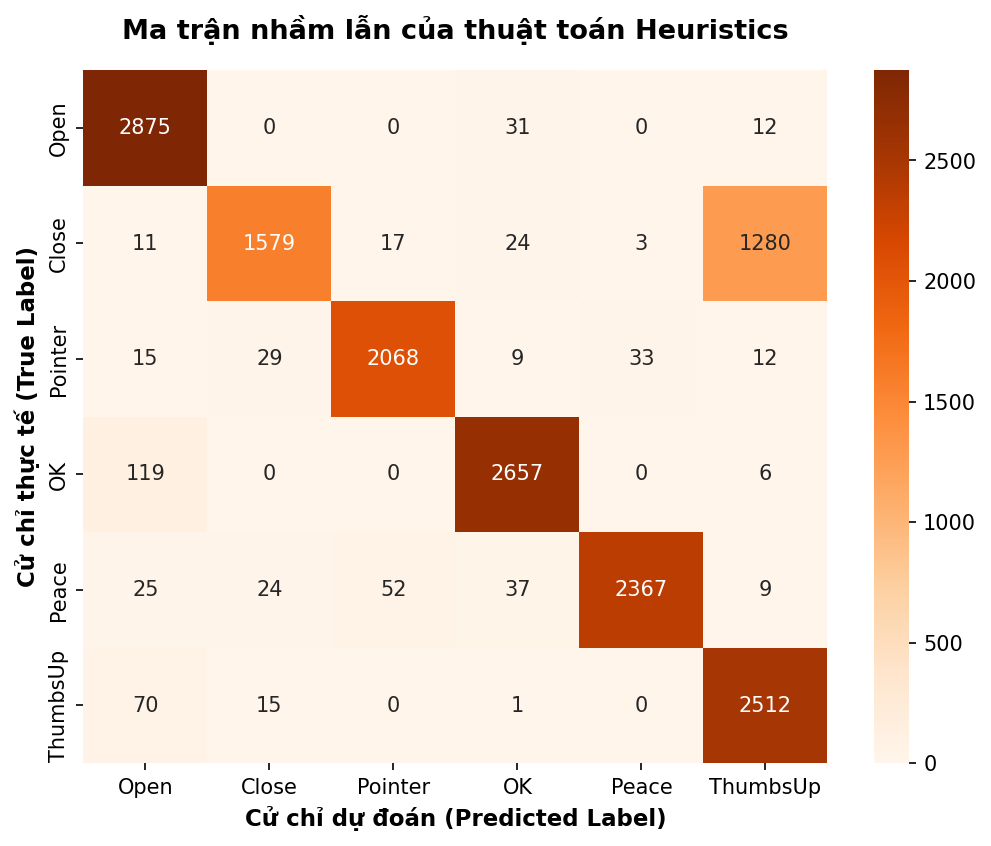

In [6]:
# 5. Vẽ và trực quan hóa Ma trận nhầm lẫn (Confusion Matrix) dạng Heatmap
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=labels, 
            yticklabels=labels)
plt.xlabel('Cử chỉ dự đoán (Predicted Label)', fontsize=11, fontweight='bold')
plt.ylabel('Cử chỉ thực tế (True Label)', fontsize=11, fontweight='bold')
plt.title('Ma trận nhầm lẫn của thuật toán Heuristics', fontsize=13, fontweight='bold', pad=15)

# Lưu hình ảnh ma trận nhầm lẫn ra file
plt.savefig("heuristics_confusion_matrix.png", bbox_inches='tight', dpi=300)
plt.show()